Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696625  72.455943  71.472447  71.629130  146322800
2020-01-06  72.267937  72.306506  70.568510  70.819208  118387200
2020-01-07  71.928070  72.533110  71.708710  72.277594  108872000
2020-01-08  73.085106  73.386423  71.631552  71.631552  132079200


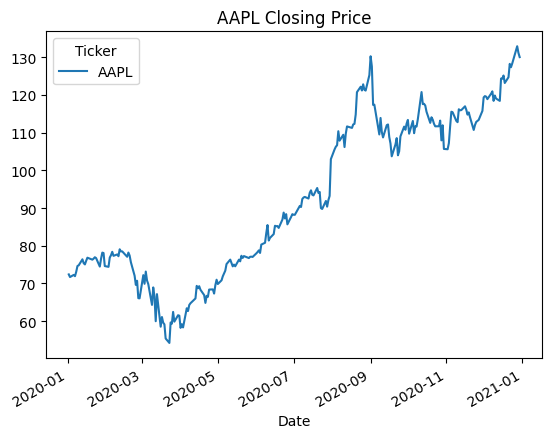

In [35]:
from quant_lab.data.loader import load_prices
import matplotlib.pyplot as plt

df = load_prices("AAPL", "2020-01-01", "2020-12-31")
print(df.head())   

df['Close'].plot(title='AAPL Closing Price')

plt.show()

Price           Close       High        Low       Open     Volume
Ticker           AAPL       AAPL       AAPL       AAPL       AAPL
Date                                                             
2020-01-02  72.400528  72.460791  71.156689  71.409793  135480400
2020-01-03  71.696632  72.455950  71.472454  71.629138  146322800
2020-01-06  72.267929  72.306499  70.568503  70.819201  118387200
2020-01-07  71.928047  72.533087  71.708687  72.277571  108872000
2020-01-08  73.085098  73.386416  71.631544  71.631544  132079200
Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  297.699005  297.717350  295.554718  296.480254  59151200
2020-01-03  295.444733  296.571870  294.244299  294.299278  77709700
2020-01-06  296.571838  296.654308  293.566140  293.685272  55653900
2020-01-07  295.738007  296.480259  295.288969  296.003732

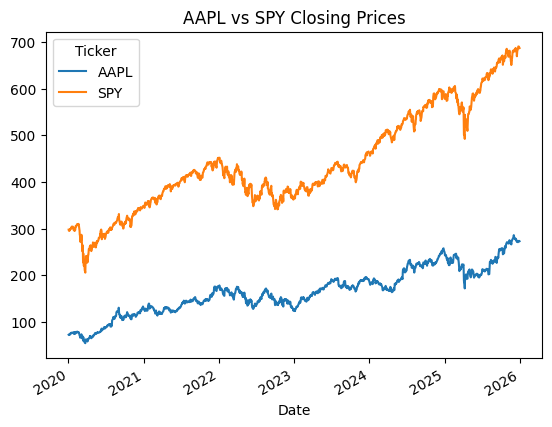

In [36]:
from quant_lab.data.loader import load_prices
import matplotlib.pyplot as plt
import pandas as pd

d1f = load_prices("AAPL", "2020-01-01", "2025-12-31")
print(d1f.head())   

d2f = load_prices("SPY", "2020-01-01", "2025-12-31")
print(d2f.head())

d3f = pd.concat([d1f['Close'], d2f['Close']], axis=1)

d3f.plot(title='AAPL vs SPY Closing Prices')
plt.show()

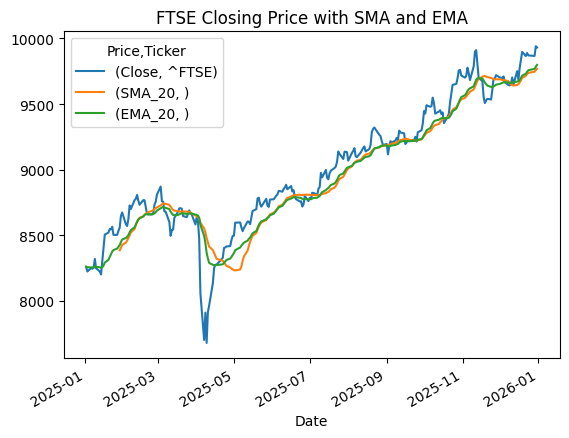

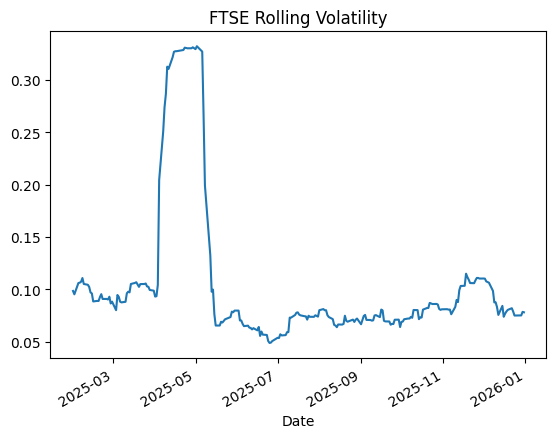

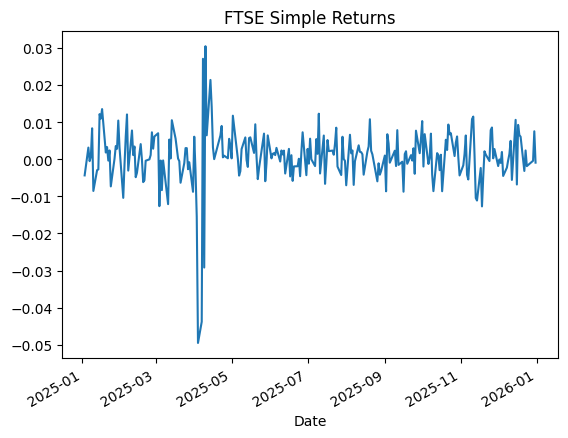

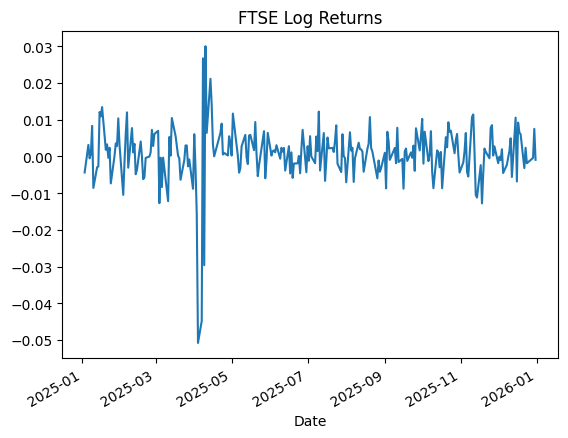

In [21]:
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
import matplotlib.pyplot as plt 

df = load_prices("^FTSE", "2025-01-01", "2026-01-01")

df['SIMPLE_RETURNS'] = simple_returns(df['Close'])
df['LOG_RETURNS'] = log_returns(df['Close'])

df['SMA_20'] = sma(df['Close'], window=20)
df['EMA_20'] = ema(df['Close'], span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

 # df['MA_CROSSOVER'] = ma_crossover_position(df['Close'], fast_window=20, slow_window=50)

df[['Close', 'SMA_20', 'EMA_20']].plot(title='FTSE Closing Price with SMA and EMA')
plt.show()

df["VOL_20"].plot(title='FTSE Rolling Volatility')
plt.show()

df['SIMPLE_RETURNS'].plot(title='FTSE Simple Returns')
plt.show()

df['LOG_RETURNS'].plot(title='FTSE Log Returns')
plt.show()

# df['MA_CROSSOVER'].plot(title='AAPL MA Crossover Position')
# plt.show()

In [10]:
import pandas as pd
import numpy as np
from quant_lab.data.loader import load_prices
from quant_lab.features.indicators import sma, ema, rolling_volatility, simple_returns, log_returns
from quant_lab.strategies.ma_crossover import ma_crossover_position
from quant_lab.engine.backtest import backtest_log_returns
import matplotlib.pyplot as plt 
from quant_lab.metrics.performance import evaluate_performance
from quant_lab.metrics.trades import generate_trade_log

df = load_prices("NVDA", "2024-01-01", "2026-01-01")
close = df["Close"]

if isinstance(close, pd.DataFrame): # converts single column dataframe to series
    close = close.iloc[1:, 0]

df['SIMPLE_RETURNS'] = simple_returns(close)
df['LOG_RETURNS'] = log_returns(close)
df['SMA_20'] = sma(close, window=20)
df['EMA_20'] = ema(close, span=20)
df["VOL_20"] = rolling_volatility(df["LOG_RETURNS"], window=20)

print(type(close))
print(close.head())
position = ma_crossover_position(close, fast_window=20, slow_window=50)

# Backtest with and without borrow costs
bt_no_borrow = backtest_log_returns(close, position, cost_per_trade=0.001)
bt_with_borrow = backtest_log_returns(close, position, cost_per_trade=0.001, borrow_cost=0.02)  # 2% annual borrow cost

print("\n--- Position Analysis ---")
print(position.value_counts())  # Count of each position type (-1, 0, 1)
print(f"Percentage of time SHORT: {(position == -1).sum() / len(position) * 100:.2f}%")
print(f"Percentage of time LONG: {(position == 1).sum() / len(position) * 100:.2f}%")

buy_hold_equity = np.exp(np.cumsum(log_returns(close)))  # Buy and hold equity curve

print("\n--- Performance Comparison ---")
print(f"Strategy final equity (no borrow): {bt_no_borrow['equity'].iloc[-1]:.4f}")
print(f"Strategy final equity (with borrow): {bt_with_borrow['equity'].iloc[-1]:.4f}")
print(f"Buy & hold final equity: {buy_hold_equity.iloc[-1]:.4f}")
print(f"Total trades executed: {bt_no_borrow['trade'].sum():.0f}")
print(f"Max Drawdown (no borrow): {bt_no_borrow['drawdown'].min()*100:.2f}%")
print(f"Max Drawdown (with borrow): {bt_with_borrow['drawdown'].min()*100:.2f}%")

plt.figure(figsize=(12, 6))
plt.plot(bt_no_borrow["equity"], label="MA Strategy (no borrow cost)", linewidth=2)
plt.plot(bt_with_borrow["equity"], label="MA Strategy (2% borrow cost)", linewidth=2)
plt.plot(buy_hold_equity, label="Buy & Hold", linewidth=2)
plt.legend()
plt.title("Strategy vs Buy & Hold (With and Without Borrow Costs)")
plt.ylabel("Equity")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(bt_no_borrow["drawdown"]*100, label="MA Strategy (no borrow cost)", linewidth=2)
plt.plot(bt_with_borrow["drawdown"]*100, label="MA Strategy (2% borrow cost)", linewidth=2)
plt.legend()
plt.title("Drawdown Comparison")
plt.ylabel("Drawdown (%)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.show()

print("\n--- Performance Metrics (No Borrow Cost) ---")
print(evaluate_performance(bt_no_borrow))
print("\n--- Performance Metrics (With Borrow Cost) ---")
print(evaluate_performance(bt_with_borrow))


<class 'pandas.Series'>
Date
2024-01-03    47.542511
2024-01-04    47.971275
2024-01-05    49.069664
2024-01-08    52.223904
2024-01-09    53.110416
Name: NVDA, dtype: float64


TypeError: backtest_log_returns() got an unexpected keyword argument 'borrow_cost'